In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
import h5flow
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from matplotlib.colors import LogNorm
import datetime, pytz

os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"


## Helper functions (thd_correct, aggregation, TRAP_NAME_MAP)

In [2]:
def thd_correct(array):
    array_shape = np.shape(array)[-1]
    num_bins = int((array_shape // 25) + 1)
    indices = np.arange(0, num_bins) * 25
    start_indices, end_indices = indices[:-1], indices[1:]
    segment_range = np.arange(25)
    index_array = start_indices[:, None] + segment_range
    sliced_data = array[..., index_array]
    ranges = np.abs(np.ptp(sliced_data, axis=-1))
    means  = np.mean(sliced_data, axis=-1)
    mask_zero = (ranges != 0)
    ranges = np.where(mask_zero, ranges, np.nan)
    means  = np.where(mask_zero, means,  np.nan)
    smallest_ordering = np.argsort(ranges, axis=-1)
    sorted_means = np.take_along_axis(means, smallest_ordering, axis=-1)
    average_mean = np.nanmean(sorted_means[..., 1:3], axis=-1)
    fallback_mean = np.mean(array, axis=-1)
    average_mean = np.where(np.isnan(average_mean), fallback_mean, average_mean)
    return array - average_mean[..., None]


TRAP_NAME_MAP = [
    dict(adc=0, channels=[4,5,6,7,8,9],      name="ACL 2.01", tpc=0, z_side="-z", position="bottom"),
    dict(adc=0, channels=[10,11,12,13,14,15], name="ACL 2.02", tpc=0, z_side="-z", position="top"),
    dict(adc=0, channels=[20,21,22,23,24,25], name="ACL 2.03", tpc=0, z_side="+z", position="bottom"),
    dict(adc=0, channels=[26,27,28,29,30,31], name="ACL 2.04", tpc=0, z_side="+z", position="top"),
    dict(adc=0, channels=[52,53,54,55,56,57], name="ACL 2.05", tpc=1, z_side="-z", position="bottom"),
    dict(adc=0, channels=[58,59,60,61,62,63], name="ACL 2.06", tpc=1, z_side="-z", position="top"),
    dict(adc=0, channels=[36,37,38,39,40,41], name="ACL 2.07", tpc=1, z_side="+z", position="bottom"),
    dict(adc=0, channels=[42,43,44,45,46,47], name="ACL 2.08", tpc=1, z_side="+z", position="top"),
    dict(adc=1, channels=[4,5,6,7,8,9],      name="LCM 100-102", tpc=0, z_side="-z", position="bottom"),
    dict(adc=1, channels=[10,11,12,13,14,15], name="LCM 103-105", tpc=0, z_side="-z", position="top"),
    dict(adc=1, channels=[20,21,22,23,24,25], name="LCM 106-108", tpc=0, z_side="+z", position="bottom"),
    dict(adc=1, channels=[26,27,28,29,30,31], name="LCM 109-111", tpc=0, z_side="+z", position="top"),
    dict(adc=1, channels=[52,53,54,55,56,57], name="LCM 112-114", tpc=1, z_side="-z", position="bottom"),
    dict(adc=1, channels=[58,59,60,61,62,63], name="LCM 115-117", tpc=1, z_side="-z", position="top"),
    dict(adc=1, channels=[36,37,38,39,40,41], name="LCM 118-120", tpc=1, z_side="+z", position="bottom"),
    dict(adc=1, channels=[42,43,44,45,46,47], name="LCM 121-123", tpc=1, z_side="+z", position="top"),
    dict(adc=2, channels=[4,5,6,7,8,9],      name="ACL 2.09", tpc=2, z_side="-z", position="bottom"),
    dict(adc=2, channels=[10,11,12,13,14,15], name="ACL 2.10", tpc=2, z_side="-z", position="top"),
    dict(adc=2, channels=[20,21,22,23,24,25], name="ACL 2.11", tpc=2, z_side="+z", position="bottom"),
    dict(adc=2, channels=[26,27,28,29,30,31], name="ACL 2.12", tpc=2, z_side="+z", position="top"),
    dict(adc=2, channels=[52,53,54,55,56,57], name="ACL 2.13", tpc=3, z_side="-z", position="bottom"),
    dict(adc=2, channels=[58,59,60,61,62,63], name="ACL 2.14", tpc=3, z_side="-z", position="top"),
    dict(adc=2, channels=[36,37,38,39,40,41], name="ACL 2.15", tpc=3, z_side="+z", position="bottom"),
    dict(adc=2, channels=[42,43,44,45,46,47], name="ACL 2.16", tpc=3, z_side="+z", position="top"),
    dict(adc=3, channels=[20,21,22,23,24,25], name="LCM 124-126", tpc=2, z_side="-z", position="bottom"),
    dict(adc=3, channels=[26,27,28,29,30,31], name="LCM 127-129", tpc=2, z_side="-z", position="top"),
    dict(adc=3, channels=[4,5,6,7,8,9],      name="LCM 130-132", tpc=2, z_side="+z", position="bottom"),
    dict(adc=3, channels=[10,11,12,13,14,15], name="LCM 133-135", tpc=2, z_side="+z", position="top"),
    dict(adc=3, channels=[52,53,54,55,56,57], name="LCM 136-138", tpc=3, z_side="-z", position="bottom"),
    dict(adc=3, channels=[58,59,60,61,62,63], name="LCM 139-141", tpc=3, z_side="-z", position="top"),
    dict(adc=3, channels=[36,37,38,39,40,41], name="LCM 142-144", tpc=3, z_side="+z", position="bottom"),
    dict(adc=3, channels=[42,43,44,45,46,47], name="LCM 145-147", tpc=3, z_side="+z", position="top"),
    dict(adc=4, channels=[42,43,44,45,46,47], name="ACL 2.17",    tpc=4, z_side="-z", position="bottom"),
    dict(adc=4, channels=[36,37,38,39,40,41], name="ACL 2.18",    tpc=4, z_side="-z", position="top"),
    dict(adc=4, channels=[52,53,54,55,56,57], name="LCM 148-150", tpc=4, z_side="+z", position="bottom"),
    dict(adc=4, channels=[58,59,60,61,62,63], name="LCM 151-153", tpc=4, z_side="+z", position="top"),
    dict(adc=4, channels=[26,27,28,29,30,31], name="ACL 2.19",    tpc=5, z_side="-z", position="bottom"),
    dict(adc=4, channels=[20,21,22,23,24,25], name="ACL 2.20",    tpc=5, z_side="-z", position="top"),
    dict(adc=4, channels=[10,11,12,13,14,15], name="ACL 2.21",    tpc=5, z_side="+z", position="bottom"),
    dict(adc=4, channels=[4,5,6,7,8,9],      name="ACL 2.22",    tpc=5, z_side="+z", position="top"),
    dict(adc=5, channels=[42,43,44,45,46,57], name="LCM 154-156", tpc=4, z_side="-z", position="bottom"),
    dict(adc=5, channels=[58,59,60,61,62,63], name="ACL 2.23",    tpc=4, z_side="+z", position="bottom"),
    dict(adc=5, channels=[52,53,54,55,56,57], name="ACL 2.24",    tpc=4, z_side="+z", position="top"),
    dict(adc=5, channels=[36,37,38,39,40,41], name="LCM 157-159", tpc=4, z_side="+z", position="top"),
    dict(adc=5, channels=[26,27,28,29,30,31], name="LCM 160-162", tpc=5, z_side="-z", position="bottom"),
    dict(adc=5, channels=[20,21,22,23,24,25], name="LCM 163-165", tpc=5, z_side="-z", position="top"),
    dict(adc=5, channels=[10,11,12,13,14,15], name="LCM 166-168", tpc=5, z_side="+z", position="bottom"),
    dict(adc=5, channels=[4,5,6,7,8,9],      name="LCM 169-171", tpc=5, z_side="+z", position="top"),
    dict(adc=6, channels=[4,5,6,7,8,9],      name="ACL 2.25", tpc=6, z_side="-z", position="bottom"),
    dict(adc=6, channels=[10,11,12,13,14,15], name="ACL 2.26", tpc=6, z_side="-z", position="top"),
    dict(adc=6, channels=[20,21,22,23,24,25], name="ACL 2.27", tpc=6, z_side="+z", position="bottom"),
    dict(adc=6, channels=[26,27,28,29,30,31], name="ACL 2.28", tpc=6, z_side="+z", position="top"),
    dict(adc=6, channels=[52,53,54,55,56,57], name="ACL 2.29", tpc=7, z_side="-z", position="bottom"),
    dict(adc=6, channels=[58,59,60,61,62,63], name="ACL 2.30", tpc=7, z_side="-z", position="top"),
    dict(adc=6, channels=[36,37,38,39,40,41], name="ACL 2.31", tpc=7, z_side="+z", position="bottom"),
    dict(adc=6, channels=[42,43,44,45,46,47], name="ACL 2.32", tpc=7, z_side="+z", position="top"),
    dict(adc=7, channels=[4,5,6,7,8,9],      name="LCM 172-174", tpc=6, z_side="-z", position="bottom"),
    dict(adc=7, channels=[10,11,12,13,14,15], name="LCM 175-177", tpc=6, z_side="-z", position="top"),
    dict(adc=7, channels=[20,21,22,23,24,25], name="LCM 178-180", tpc=6, z_side="+z", position="bottom"),
    dict(adc=7, channels=[26,27,28,29,30,31], name="LCM 181-183", tpc=6, z_side="+z", position="top"),
    dict(adc=7, channels=[52,53,54,55,56,57], name="LCM 184-186", tpc=7, z_side="-z", position="bottom"),
    dict(adc=7, channels=[58,59,60,61,62,63], name="LCM 187-189", tpc=7, z_side="-z", position="top"),
    dict(adc=7, channels=[36,37,38,39,40,41], name="LCM 190-192", tpc=7, z_side="+z", position="bottom"),
    dict(adc=7, channels=[42,43,44,45,46,47], name="LCM 193-195", tpc=7, z_side="+z", position="top"),
]

# ACL/LCM trap indices, TPC 6 excluded (sparking)
acl_idx = np.array([i for i, e in enumerate(TRAP_NAME_MAP) if e["name"].startswith("ACL") and e["tpc"] != 6])
lcm_idx = np.array([i for i, e in enumerate(TRAP_NAME_MAP) if e["name"].startswith("LCM") and e["tpc"] != 6])
print(f"ACL traps (excl. TPC 6): {len(acl_idx)},  LCM traps (excl. TPC 6): {len(lcm_idx)}")

# TPC label for each trap in acl_idx / lcm_idx (used for per-TPC analysis)
acl_tpc = np.array([TRAP_NAME_MAP[i]["tpc"] for i in acl_idx])
lcm_tpc = np.array([TRAP_NAME_MAP[i]["tpc"] for i in lcm_idx])


def sum_to_traps(samples, trap_map):
    n_ev, _, _, n_t = samples.shape
    out = np.zeros((n_ev, len(trap_map), n_t), dtype=np.float64)
    for i, entry in enumerate(trap_map):
        out[:, i, :] = samples[:, entry["adc"], :, :][:, entry["channels"], :].sum(axis=1)
    return out


ACL traps (excl. TPC 6): 28,  LCM traps (excl. TPC 6): 28


## File catalogue — map every file to its UTC and Chicago timestamp

In [3]:
# Data lives in a single folder; each file covers ~30 s of data.
# utime_ms in /light/events/ gives Unix time in milliseconds.
# Chicago = UTC-6 (CST) in December.

DATA_FOLDER = "/global/cfs/cdirs/dune/www/data/2x2/nearline_run2/flowed_light/source_dtg_bin2/two_trig_40us_period_500tick/hv_65kV_beamC_25uA/dtg_30min_thenDecay/"
chicago = pytz.timezone("America/Chicago")

all_files = sorted(
    os.path.join(DATA_FOLDER, f)
    for f in os.listdir(DATA_FOLDER)
    if f.endswith(".hdf5")
)
print(f"Total files found: {len(all_files)}")


Total files found: 1517


In [4]:

i = 0
# Read the first event's timestamp from each file — fast (single read per file)
catalogue = []  # list of (path, t_chicago, n_events)
for path in all_files:
    if i % 100 == 0:
        print(f"Processing file {i}/{len(all_files)}: {os.path.basename(path)}")
    i += 1
    try:
        with h5py.File(path, "r") as h:
            utime_ms = h["light/events/data"]["utime_ms"]
            if len(utime_ms) == 0:
                continue
            t_unix_s = float(utime_ms[0][0]) / 1e3
            t_chicago = datetime.datetime.fromtimestamp(t_unix_s, tz=chicago)
            n_ev = len(utime_ms)
        catalogue.append({"path": path, "t_chicago": t_chicago, "n_events": n_ev})
    except Exception as e:
        print(f"  Skipping {os.path.basename(path)}: {e}")


Processing file 0/1517: mpd_run_data_rctl_978_p0.FLOW.hdf5


KeyboardInterrupt: 

In [ ]:

cat_df = pd.DataFrame(catalogue).sort_values("t_chicago").reset_index(drop=True)
print(f"Files catalogued: {len(cat_df)}")
print(f"Start : {cat_df['t_chicago'].iloc[0]}")
print(f"End   : {cat_df['t_chicago'].iloc[-1]}")
print(f"Total events: {cat_df['n_events'].sum():,}")


Files catalogued: 1517
Start : 2025-12-12 17:56:39.516000-06:00
End   : 2025-12-13 16:43:41.950000-06:00
Total events: 6,405,670


In [4]:
# Save the catalogue for later use (skip the 11-minute build next time)
# cat_df.to_csv("dtg_file_catalogue.csv", index=False)

# To reload without rebuilding:
cat_df = pd.read_csv("dtg_file_catalogue.csv")
cat_df["t_chicago"] = pd.to_datetime(cat_df["t_chicago"], format="ISO8601").dt.tz_convert(chicago)


In [5]:
cat_df.head(20)

,path,t_chicago,n_events
0,/global/cfs/cdirs/dune/www/data/2x2/nearline_r...,2025-12-12 17:56:39.516000-06:00,2801
1,/global/cfs/cdirs/dune/www/data/2x2/nearline_r...,2025-12-12 17:56:53.502000-06:00,6043
2,/global/cfs/cdirs/dune/www/data/2x2/nearline_r...,2025-12-12 17:57:23.697000-06:00,6039
3,/global/cfs/cdirs/dune/www/data/2x2/nearline_r...,2025-12-12 17:57:53.848000-06:00,6040
4,/global/cfs/cdirs/dune/www/data/2x2/nearline_r...,2025-12-12 17:58:24.006000-06:00,6038
5,/global/cfs/cdirs/dune/www/data/2x2/nearline_r...,2025-12-12 17:58:54.155000-06:00,6034
6,/global/cfs/cdirs/dune/www/data/2x2/nearline_r...,2025-12-12 17:59:24.306000-06:00,6048
7,/global/cfs/cdirs/dune/www/data/2x2/nearline_r...,2025-12-12 17:59:54.498000-06:00,6043
8,/global/cfs/cdirs/dune/www/data/2x2/nearline_r...,2025-12-12 18:00:24.657000-06:00,6042
9,/global/cfs/cdirs/dune/www/data/2x2/nearline_r...,2025-12-12 18:00:54.822000-06:00,6034


## Define time windows

In [6]:
# DTG turns off after the first ~30 minutes of external triggers.
# Edit DTG_OFF to the actual switchover time once you've seen the catalogue.
DTG_OFF = datetime.datetime(2025, 12, 12, 17, 36, 0, tzinfo=chicago) # Should be 17:36 according to the run log

# Good spike-free windows identified from the rate monitor plot.
# Each entry: (label, centre_time_chicago).  We'll take ±1 min around each centre.
# For the long clean stretch (1:15–3:15) we add several 2-min windows.
WINDOW_HALF = datetime.timedelta(minutes=2)  # ±1 min → 2-min windows

good_windows = [
    # label,   centre time (Chicago)
    # ("t036m",  datetime.datetime(2025, 12, 12, 18,  6, 0, tzinfo=chicago)),
    # ("t060m",  datetime.datetime(2025, 12, 12, 18, 36, 0, tzinfo=chicago)), # too much spiking in the 18:30–18:40 range
    ("t069m",  datetime.datetime(2025, 12, 12, 18, 45, 0, tzinfo=chicago)),
    ("t099m",  datetime.datetime(2025, 12, 12, 19, 15, 0, tzinfo=chicago)),
    ("t129m",  datetime.datetime(2025, 12, 12, 19, 45, 0, tzinfo=chicago)),
    ("t189m",  datetime.datetime(2025, 12, 12, 20, 45, 0, tzinfo=chicago)),
    ("t219m",  datetime.datetime(2025, 12, 12, 21, 15, 0, tzinfo=chicago)),
    ("t264m",  datetime.datetime(2025, 12, 12, 22,  0, 0, tzinfo=chicago)),
    ("t309m",  datetime.datetime(2025, 12, 12, 22, 45, 0, tzinfo=chicago)),
    ("t399m",  datetime.datetime(2025, 12, 13,  0, 15, 0, tzinfo=chicago)),
    ("t459m",  datetime.datetime(2025, 12, 13,  1, 15, 0, tzinfo=chicago)),
    ("t519m",  datetime.datetime(2025, 12, 13,  2, 15, 0, tzinfo=chicago)),
    ("t564m",  datetime.datetime(2025, 12, 13,  3, 0, 0, tzinfo=chicago)),
    ("t699m",  datetime.datetime(2025, 12, 13,  5, 15, 0, tzinfo=chicago)),
    ("t759m",  datetime.datetime(2025, 12, 13,  6, 15, 0, tzinfo=chicago))
]

# Map each window to the files that fall inside it
def files_in_window(centre, half=WINDOW_HALF):
    lo = centre - half
    hi = centre + half
    return cat_df[(cat_df["t_chicago"] >= lo) & (cat_df["t_chicago"] < hi)]["path"].tolist()

for label, centre in good_windows:
    paths = files_in_window(centre)
    dt_min = (centre - DTG_OFF).total_seconds() / 60
    print(f"{label:15s}  Δt={dt_min:+7.1f} min   files={len(paths):3d}  "
          f"events≈{sum(cat_df[cat_df['path'].isin(paths)]['n_events'])}")


t069m            Δt=  +69.0 min   files=  8  events≈34270
t099m            Δt=  +99.0 min   files=  4  events≈19874
t129m            Δt= +129.0 min   files=  4  events≈18112
t189m            Δt= +189.0 min   files=  4  events≈16307
t219m            Δt= +219.0 min   files=  4  events≈15586
t264m            Δt= +264.0 min   files=  4  events≈14671
t309m            Δt= +309.0 min   files=  4  events≈13896
t399m            Δt= +399.0 min   files=  4  events≈12769
t459m            Δt= +459.0 min   files=  4  events≈12248
t519m            Δt= +519.0 min   files=  4  events≈11916
t564m            Δt= +564.0 min   files=  4  events≈11500
t699m            Δt= +699.0 min   files=  4  events≈11178
t759m            Δt= +759.0 min   files=  4  events≈11163


## Processing function — returns per-trap fprompt and integral arrays

In [7]:
DETECTOR             = "lcm"  # "lcm" or "acl"
CHUNK_SIZE           = 300
PEAK_TICK            = 82     # fixed peak position — confirmed from average waveform
SAT_THRESHOLD        = 59000
PILEUP_MIN_REL_HEIGHT = 0.3
PILEUP_LOOKBACK       = 15    # ticks (1.2 µs); natural tail drops ~53% over this window,
                             #   making noise-induced false positives essentially impossible

# Prompt and total windows are now fixed index offsets from PEAK_TICK
_prompt_slice = slice(PEAK_TICK - 5, PEAK_TICK + 10)   # 15 ticks
_total_slice  = slice(PEAK_TICK - 5, PEAK_TICK + 195)  # 200 ticks


def process_files(paths, chunk_size=CHUNK_SIZE):
    """
    Process HDF5 files in memory-safe chunks with a fixed peak position.
    Returns flat arrays (one entry per good trap per event):
        fprompt_acl/lcm, energy_acl/lcm, n_peaks_acl/lcm, livetime_s
    """
    fp_acl, en_acl, np_acl = [], [], []
    fp_lcm, en_lcm, np_lcm = [], [], []
    livetime_s = 0.0

    for path in paths:
        with h5py.File(path, "r") as h:
            utime_ms = h["light/events/data"]["utime_ms"]
            n_total  = len(utime_ms)
            if n_total >= 2:
                livetime_s += (float(utime_ms[-1][0]) - float(utime_ms[0][0])) / 1e3
            wvfm_ds = h["/light/wvfm/data"]["samples"]

            for start in range(0, n_total, chunk_size):
                stop = min(start + chunk_size, n_total)

                raw        = wvfm_ds[start:stop, :, :, :500]
                samples    = thd_correct(raw.astype(np.float32)); del raw
                saturated  = (samples >= SAT_THRESHOLD).any(axis=(-1, -2, -3))
                trap_wvfms = sum_to_traps(samples, TRAP_NAME_MAP).astype(np.float32); del samples
                # trap_wvfms: (chunk, n_traps, 500)

                # Fixed-window fprompt — no argmax, no late-peak cut
                fprompt_num = trap_wvfms[:, :, _prompt_slice].sum(axis=-1)
                fprompt_den = trap_wvfms[:, :, _total_slice ].sum(axis=-1)
                trap_fprompts  = fprompt_num / fprompt_den
                trap_integrals = trap_wvfms.sum(axis=-1)

                # Pileup: the scintillation tail is always decreasing after the peak.
                # If the waveform is higher at any tick than it was PILEUP_LOOKBACK ticks
                # earlier (and above the amplitude threshold), a second event is present.
                # Adjacent-tick comparison is too sensitive to noise; a multi-tick lookback
                # is robust because the natural tail drop over N ticks >> noise amplitude.
                _past        = trap_wvfms[:, :, PEAK_TICK     : _total_slice.stop - PILEUP_LOOKBACK]
                _later       = trap_wvfms[:, :, PEAK_TICK + PILEUP_LOOKBACK : _total_slice.stop]
                rising       = _later > _past
                above_thresh = _later > (PILEUP_MIN_REL_HEIGHT
                                         * trap_wvfms[:, :, PEAK_TICK:PEAK_TICK + 1])
                pileup        = (rising & above_thresh).any(axis=-1)
                n_peaks_traps = np.where(pileup, np.int8(2), np.int8(1))
                del _past, _later, rising, above_thresh, pileup

                good = ~saturated
                fp_acl.append(trap_fprompts[good][:, acl_idx])
                en_acl.append(trap_integrals[good][:, acl_idx])
                np_acl.append(n_peaks_traps[good][:, acl_idx])
                fp_lcm.append(trap_fprompts[good][:, lcm_idx])
                en_lcm.append(trap_integrals[good][:, lcm_idx])
                np_lcm.append(n_peaks_traps[good][:, lcm_idx])

    # Keep 2D shape (n_events, n_traps) so callers can slice by TPC
    def cat(lst): return np.concatenate(lst, axis=0) if lst else np.array([]).reshape(0, 0)
    return {
        "fprompt_acl": cat(fp_acl), "energy_acl": cat(en_acl), "n_peaks_acl": cat(np_acl),
        "fprompt_lcm": cat(fp_lcm), "energy_lcm": cat(en_lcm), "n_peaks_lcm": cat(np_lcm),
        "livetime_s":  livetime_s,
    }


## Process all windows  *(runs in a few minutes)*

/tmp/ipykernel_1014610/1182266732.py:16: RuntimeWarning: Mean of empty slice
  average_mean = np.nanmean(sorted_means[..., 1:3], axis=-1)


Peak tick in average waveform: 81


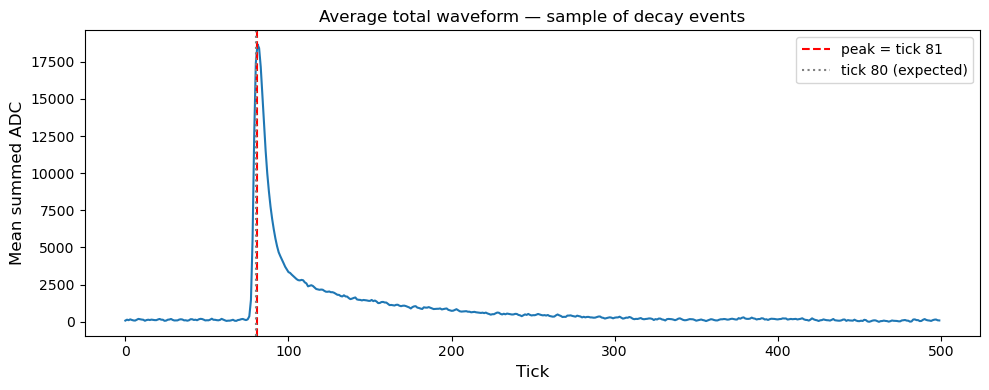

In [8]:
# Quick check: average total waveform over a sample of events from one file.
# This confirms the expected peak position before we hard-code it.

N_CHECK = 500   # events to average

sample_path = files_in_window(dict(good_windows)["t069m"])[0]
wvfm_sum = None
n_used = 0

with h5py.File(sample_path, "r") as h:
    raw = h["/light/wvfm/data"]["samples"][:N_CHECK, :, :, :500].astype(np.float32)

samples    = thd_correct(raw); del raw
trap_wvfms = sum_to_traps(samples, TRAP_NAME_MAP).astype(np.float32); del samples
total_wvfm = trap_wvfms.sum(axis=1)   # (n_ev, 500)

avg_wvfm = total_wvfm.mean(axis=0)
peak_tick = int(avg_wvfm.argmax())
print(f"Peak tick in average waveform: {peak_tick}")

plt.figure(figsize=(10, 4))
plt.plot(avg_wvfm, lw=1.5)
plt.axvline(peak_tick, color="red", ls="--", label=f"peak = tick {peak_tick}")
plt.axvline(80, color="gray", ls=":", label="tick 80 (expected)")
plt.xlabel("Tick", fontsize=12)
plt.ylabel("Mean summed ADC", fontsize=12)
plt.title("Average total waveform — sample of decay events", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()


In [30]:
# Interactive waveform browser — shows only (event, trap) pairs with a real signal.
# Pairs are pre-filtered by peak height at PEAK_TICK so you never scroll through noise.

import ipywidgets as widgets
from IPython.display import display

# ── Settings ──────────────────────────────────────────────────────────────
INSPECT_WINDOW = "t069m"   # any label from good_windows
N_INSPECT      = 80        # events to load from the file
MIN_PEAK_ADC   = 10000       # minimum trap peak height (ADC counts) to show
# ──────────────────────────────────────────────────────────────────────────

inspect_path = files_in_window(dict(good_windows)[INSPECT_WINDOW])[0]
print(f"Loading {N_INSPECT} events from:\n  {inspect_path}")

with h5py.File(inspect_path, "r") as h:
    raw = h["/light/wvfm/data"]["samples"][:N_INSPECT, :, :, :500]

samples    = thd_correct(raw.astype(np.float32))
trap_wvfms = sum_to_traps(samples, TRAP_NAME_MAP).astype(np.float32)  # (N, 64, 500)

# Per-trap quantities
_fp_num = trap_wvfms[:, :, _prompt_slice].sum(axis=-1)
_fp_den = trap_wvfms[:, :, _total_slice ].sum(axis=-1)
_fp_all = _fp_num / np.where(_fp_den != 0, _fp_den, np.nan)
_en_all = _fp_den * 0.004 * 0.01   # PE (reuse total-window integral)

from scipy.signal import find_peaks as _find_peaks
# n_peaks is computed live per (event, trap) in _plot() using scipy.find_peaks.

# ── Pre-filter: keep only (event, trap) pairs above MIN_PEAK_ADC ──────────
peak_height = trap_wvfms[:, :, PEAK_TICK]          # (N, 64)
ev_idx, tr_idx = np.where(peak_height >= MIN_PEAK_ADC)

if len(ev_idx) == 0:
    print(f"No pairs found above {MIN_PEAK_ADC} ADC — lower MIN_PEAK_ADC.")
else:
    print(f"Found {len(ev_idx)} (event, trap) pairs above {MIN_PEAK_ADC} ADC counts.")

    t_us = np.arange(500) * 0.016   # µs (16 ns/tick)

    def _plot(pair_i):
        ev  = ev_idx[pair_i]
        tr  = tr_idx[pair_i]
        info = TRAP_NAME_MAP[tr]
        wvfm = trap_wvfms[ev, tr, :]
        fp   = _fp_all[ev, tr]
        en   = _en_all[ev, tr]
        pk   = peak_height[ev, tr]
        # Count peaks in the total window with scipy.find_peaks
        w_win = trap_wvfms[ev, tr, _total_slice]
        _pks, _ = _find_peaks(w_win,
                               height=PILEUP_MIN_REL_HEIGHT * pk,
                               distance=5)
        np_ = max(len(_pks), 1)

        fig, ax = plt.subplots(figsize=(13, 4))
        ax.plot(t_us, wvfm, color="k", lw=1.2)

        ax.axvspan(t_us[_prompt_slice.start], t_us[_prompt_slice.stop - 1],
                   alpha=0.25, color="tab:blue",   label="prompt")
        ax.axvspan(t_us[_prompt_slice.stop],  t_us[_total_slice.stop  - 1],
                   alpha=0.10, color="tab:orange", label="total (rest)")
        ax.axvline(t_us[PEAK_TICK], ls=":", color="gray", lw=1)
        ax.axhline(PILEUP_MIN_REL_HEIGHT * trap_wvfms[ev, tr, PEAK_TICK],
                   ls="--", color="tab:red", lw=1, label="pileup threshold")

        fp_str = f"{fp:.3f}" if np.isfinite(fp) else "nan"
        ax.set_title(
            f"Pair {pair_i}/{len(ev_idx)-1}  |  Event {ev}, Trap {tr}: {info['name']}  "
            f"(TPC {info['tpc']}, {info['z_side']}, {info['position']})"
            f"peak = {pk:.0f} ADC    fprompt = {fp_str}    "
            f"energy = {en:.2f} MeV (estimate)    n_peaks = {np_}",
            fontsize=11
        )
        ax.set_xlabel("Time (µs)", fontsize=12)
        ax.set_ylabel("ADC counts (baseline-subtracted)", fontsize=12)

        ax.legend(fontsize=10, loc="upper right")
        ax.minorticks_on()
        ax.tick_params(direction="in", which="both")
        plt.tight_layout()
        # plt.ylim(0,10)
        plt.show()

    widgets.interact(
        _plot,
        pair_i=widgets.IntSlider(min=0, max=len(ev_idx) - 1, step=1, value=0,
                                 description="Pair #", continuous_update=False,
                                 layout=widgets.Layout(width="70%")),
    )


Loading 80 events from:
  /global/cfs/cdirs/dune/www/data/2x2/nearline_run2/flowed_light/source_dtg_bin2/two_trig_40us_period_500tick/hv_65kV_beamC_25uA/dtg_30min_thenDecay/mpd_run_data_rctl_979_p7.FLOW.hdf5
Found 44 (event, trap) pairs above 10000 ADC counts.


/tmp/ipykernel_1014610/1182266732.py:16: RuntimeWarning: Mean of empty slice
  average_mean = np.nanmean(sorted_means[..., 1:3], axis=-1)


interactive(children=(IntSlider(value=0, continuous_update=False, description='Pair #', layout=Layout(width='7…

In [10]:
results = {}   # label → dict from process_files()

for label, centre in good_windows:
    paths = files_in_window(centre)
    if not paths:
        print(f"{label}: no files found, skipping")
        continue
    print(f"Processing {label}  ({len(paths)} files) ...", end=" ", flush=True)
    results[label] = process_files(paths)
    r = results[label]
    n_ev = r["fprompt_acl"].shape[0] if r["fprompt_acl"].ndim == 2 else 0
    print(f"done  — {n_ev:,} events  livetime={r['livetime_s']:.1f}s")


Processing t069m  (8 files) ... 

/tmp/ipykernel_1014610/1182266732.py:16: RuntimeWarning: Mean of empty slice
  average_mean = np.nanmean(sorted_means[..., 1:3], axis=-1)
/tmp/ipykernel_1014610/860347934.py:44: RuntimeWarning: divide by zero encountered in divide
  trap_fprompts  = fprompt_num / fprompt_den


done  — 33,212 events  livetime=242.1s
Processing t099m  (4 files) ... done  — 19,236 events  livetime=243.2s
Processing t129m  (4 files) ... done  — 17,728 events  livetime=243.3s
Processing t189m  (4 files) ... done  — 15,947 events  livetime=242.9s
Processing t219m  (4 files) ... done  — 15,229 events  livetime=242.8s
Processing t264m  (4 files) ... done  — 14,278 events  livetime=242.9s
Processing t309m  (4 files) ... done  — 13,517 events  livetime=242.1s
Processing t399m  (4 files) ... done  — 12,386 events  livetime=240.5s
Processing t459m  (4 files) ... done  — 11,857 events  livetime=240.4s
Processing t519m  (4 files) ... done  — 11,524 events  livetime=240.7s
Processing t564m  (4 files) ... done  — 11,116 events  livetime=240.8s
Processing t699m  (4 files) ... done  — 10,749 events  livetime=241.4s
Processing t759m  (4 files) ... done  — 10,674 events  livetime=240.8s


In [11]:
# Load cosmics background from the matched-flow Run 2 data.
# These are the same files used in cosmic_fprompt_spectrum.ipynb.
# A handful of files gives enough statistics since the cosmic rate is high.

COSMIC_FOLDER = "/global/cfs/cdirs/dune/users/mnuland/run2flow/matched_flowed_run2_new_gains/"
N_COSMIC_FILES = 10   # increase for better statistics; each file takes ~30 s to process

cosmic_files = sorted(
    os.path.join(COSMIC_FOLDER, f)
    for f in os.listdir(COSMIC_FOLDER)
    if f.endswith(".hdf5")
)[:N_COSMIC_FILES]

print(f"Processing {len(cosmic_files)} cosmic files for background ...")
bkg_result = process_files(cosmic_files)
print(f"  ACL trap-entries: {len(bkg_result['fprompt_acl']):,}")
print(f"  LCM trap-entries: {len(bkg_result['fprompt_lcm']):,}")
print(f"  Livetime: {bkg_result['livetime_s']:.1f} s")


Processing 10 cosmic files for background ...


/tmp/ipykernel_1014610/1182266732.py:16: RuntimeWarning: Mean of empty slice
  average_mean = np.nanmean(sorted_means[..., 1:3], axis=-1)
/tmp/ipykernel_1014610/860347934.py:44: RuntimeWarning: divide by zero encountered in divide
  trap_fprompts  = fprompt_num / fprompt_den
/tmp/ipykernel_1014610/860347934.py:44: RuntimeWarning: invalid value encountered in divide
  trap_fprompts  = fprompt_num / fprompt_den


  ACL trap-entries: 142,237
  LCM trap-entries: 142,237
  Livetime: 7839.2 s


## fprompt vs energy 2D histograms per window

More than 10 windows; plotting every third one (total plotted: 5)


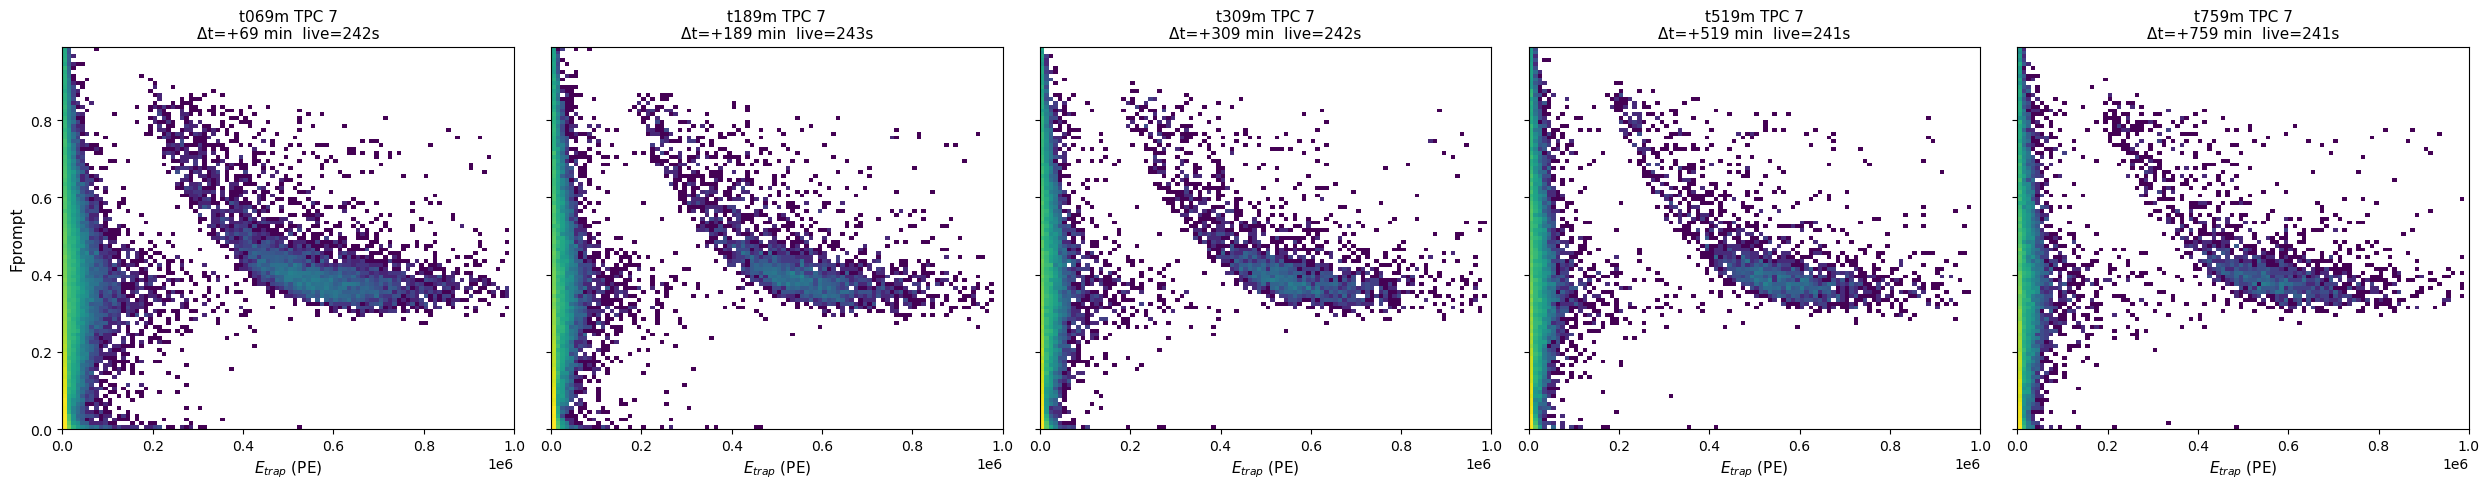

In [12]:
# Compare all decay windows side-by-side (detector type set by DETECTOR variable above)
DETECTOR   = "lcm"   # "acl" or "lcm"
TPC_FILTER = 7    # None = all TPCs, or set to a single TPC int (e.g. 0, 1, …, 7) to restrict

EN_BINS = np.arange(0, 1000000, 10000)
FP_BINS = np.arange(0, 1, 0.01)

def _select(res, det, tpc_filter=None):
    """Return flat fp, en, npe arrays, optionally restricted to one TPC."""
    fp  = res[f"fprompt_{det}"]   # (n_ev, n_traps)
    en  = res[f"energy_{det}"]
    npe = res[f"n_peaks_{det}"]
    tpc_arr = acl_tpc if det == "acl" else lcm_tpc
    if tpc_filter is not None:
        col = tpc_arr == tpc_filter
        fp, en, npe = fp[:, col], en[:, col], npe[:, col]
    return fp.ravel(), en.ravel(), npe.ravel()

n_windows = len(results)
# plot only every other window if there are many, to avoid overwhelming the plot
if n_windows > 10:
    results2 = dict(list(results.items())[::3])
    print(f"More than 10 windows; plotting every third one (total plotted: {len(results2)})")
n_windows = len(results2)
fig, axes = plt.subplots(1, n_windows, figsize=(5 * n_windows, 5),
                         sharey=True, sharex=True)

for ax, (label, res) in zip(axes, results2.items()):
    fp, en, npe = _select(res, DETECTOR, TPC_FILTER)
    en  = en  # gain and PDE correction to get PE
    liv = res["livetime_s"]

    clean = np.isfinite(fp) & np.isfinite(en) & (npe <= 2)
    centre_time = dict(good_windows)[label]
    dt_min = (centre_time - DTG_OFF).total_seconds() / 60

    tpc_label = f" TPC {TPC_FILTER}" if TPC_FILTER is not None else ""
    ax.hist2d(en[clean], fp[clean], bins=[EN_BINS, FP_BINS], norm=LogNorm())
    ax.set_title(f"{label}{tpc_label}\nΔt={dt_min:+.0f} min  live={liv:.0f}s", fontsize=11)
    ax.set_xlabel("$E_{trap}$ (PE)", fontsize=11)
    ax.set_xlim(0, 1000000)

axes[0].set_ylabel("Fprompt", fontsize=11)
plt.tight_layout()
plt.show()


More than 10 windows; plotting every third one (total plotted: 5)


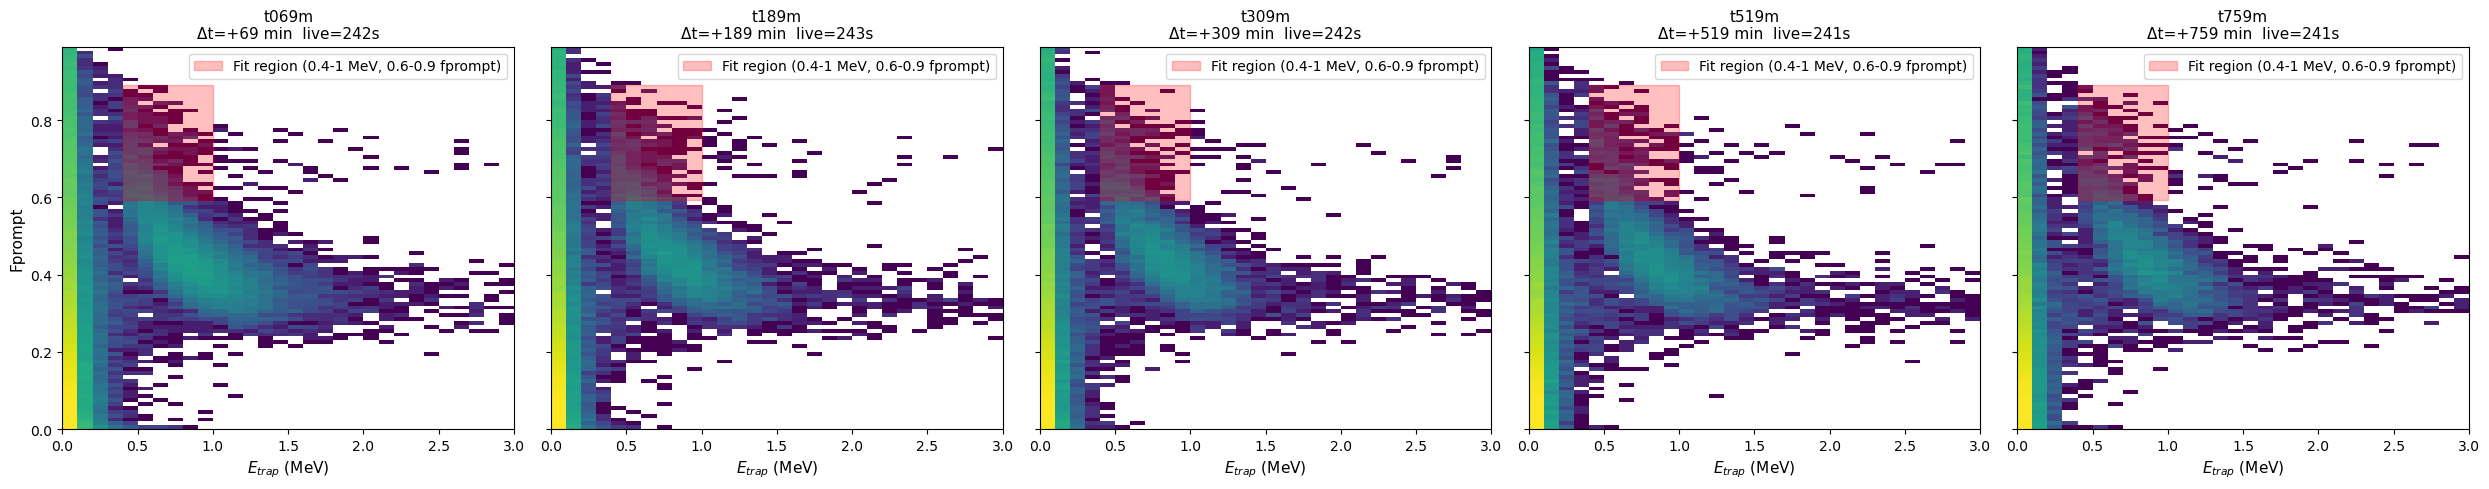

In [37]:
# Compare all decay windows side-by-side (detector type set by DETECTOR variable above)
DETECTOR   = "acl"   # "acl" or "lcm"
TPC_FILTER = None    # None = all TPCs, or set to a single TPC int (e.g. 0, 1, …, 7) to restrict

EN_BINS = np.arange(0, 100, 0.1)
FP_BINS = np.arange(0, 1, 0.01)

# Edit these to match the Ar-41 region you see in the 2D histograms above.
# Ar-41 beta endpoint 2.49 MeV — expect low fprompt (electronic recoil), moderate energy.
AR41_FP_MIN  = 0.6
AR41_FP_MAX  = 0.9
AR41_EN_MIN  = 0.4   # PE — adjust after looking at the histograms
AR41_EN_MAX  = 1   # PE

def _select(res, det, tpc_filter=None):
    """Return flat fp, en, npe arrays, optionally restricted to one TPC."""
    fp  = res[f"fprompt_{det}"]   # (n_ev, n_traps)
    en  = res[f"energy_{det}"]
    npe = res[f"n_peaks_{det}"]
    tpc_arr = acl_tpc if det == "acl" else lcm_tpc
    if tpc_filter is not None:
        col = tpc_arr == tpc_filter
        fp, en, npe = fp[:, col], en[:, col], npe[:, col]
    return fp.ravel(), en.ravel(), npe.ravel()

n_windows = len(results)
# plot only every other window if there are many, to avoid overwhelming the plot
if n_windows > 10:
    results2 = dict(list(results.items())[::3])
    print(f"More than 10 windows; plotting every third one (total plotted: {len(results2)})")
n_windows = len(results2)
fig, axes = plt.subplots(1, n_windows, figsize=(5 * n_windows, 5),
                         sharey=True, sharex=True)

for ax, (label, res) in zip(axes, results2.items()):
    fp, en, npe = _select(res, DETECTOR, TPC_FILTER)
    en  = en /147 * 0.004 /4 # gain and PDE correction to get MeV
    liv = res["livetime_s"]

    clean = np.isfinite(fp) & np.isfinite(en) & (npe <= 2)
    centre_time = dict(good_windows)[label]
    dt_min = (centre_time - DTG_OFF).total_seconds() / 60

    tpc_label = f" TPC {TPC_FILTER}" if TPC_FILTER is not None else ""
    ax.hist2d(en[clean], fp[clean], bins=[EN_BINS, FP_BINS], norm=LogNorm())
    ax.set_title(f"{label}{tpc_label}\nΔt={dt_min:+.0f} min  live={liv:.0f}s", fontsize=11)
    ax.set_xlabel("$E_{trap}$ (MeV)", fontsize=11)
    ax.set_xlim(0, 3)

# plot a box around the Ar-41 region
    ax.axvspan(AR41_EN_MIN, AR41_EN_MAX, AR41_FP_MIN, AR41_FP_MAX, color="red", alpha=0.25, label=f"Fit region ({AR41_EN_MIN}-{AR41_EN_MAX} MeV, {AR41_FP_MIN}-{AR41_FP_MAX} fprompt)")
    ax.legend(fontsize=10)

axes[0].set_ylabel("Fprompt", fontsize=11)
plt.tight_layout()
plt.show()

## Define signal region and extract rate vs time for exponential fit

In [38]:

# TPC_FILTER: None = all TPCs, or set to e.g. 0, 1, … for spatial check
# (uses the same _select() helper defined in the 2D histogram cell)

t_min_arr, rate_arr, rate_err_arr = [], [], []

for label, res in results.items():

    centre_time = dict(good_windows)[label]
    dt_min = (centre_time - DTG_OFF).total_seconds() / 60

    fp, en, npe = _select(res, DETECTOR, TPC_FILTER)
    en  = en /147 * 0.004 /4 # gain and PDE correction to get MeV
    liv = res["livetime_s"]

    clean     = np.isfinite(fp) & np.isfinite(en)
    in_region = clean & (fp >= AR41_FP_MIN) & (fp < AR41_FP_MAX) & (en >= AR41_EN_MIN) & (en < AR41_EN_MAX)
    count = in_region.sum()
    rate  = count / liv if liv > 0 else np.nan

    # Background subtraction using cosmics (scaled to same livetime)
    bkg_fp, bkg_en, bkg_npe = _select(bkg_result, DETECTOR, TPC_FILTER)
    bkg_en  = bkg_en
    bkg_liv = bkg_result["livetime_s"]
    bkg_clean = (bkg_npe == 1) & np.isfinite(bkg_fp) & np.isfinite(bkg_en)
    bkg_in    = bkg_clean & (bkg_fp >= AR41_FP_MIN) & (bkg_fp < AR41_FP_MAX) & (bkg_en >= AR41_EN_MIN) & (bkg_en < AR41_EN_MAX)
    bkg_rate  = bkg_in.sum() / bkg_liv if bkg_liv > 0 else 0.0
    rate -= bkg_rate

    rate_err = np.sqrt(count) / liv if liv > 0 else np.nan

    t_min_arr.append(dt_min)
    rate_arr.append(rate)
    rate_err_arr.append(rate_err)
    tpc_label = f" TPC {TPC_FILTER}" if TPC_FILTER is not None else ""
    print(f"{label:15s}{tpc_label}  Δt={dt_min:+7.1f} min  count={count:5d}  rate={rate:.3f} Hz")

t_min_arr    = np.array(t_min_arr)
rate_arr     = np.array(rate_arr)
rate_err_arr = np.array(rate_err_arr)
print(f"Background rate (cosmics): {bkg_rate:.3f} Hz")


t069m            Δt=  +69.0 min  count=  870  rate=3.593 Hz
t099m            Δt=  +99.0 min  count=  646  rate=2.657 Hz
t129m            Δt= +129.0 min  count=  614  rate=2.524 Hz
t189m            Δt= +189.0 min  count=  530  rate=2.182 Hz
t219m            Δt= +219.0 min  count=  540  rate=2.224 Hz
t264m            Δt= +264.0 min  count=  498  rate=2.050 Hz
t309m            Δt= +309.0 min  count=  471  rate=1.945 Hz
t399m            Δt= +399.0 min  count=  404  rate=1.680 Hz
t459m            Δt= +459.0 min  count=  429  rate=1.784 Hz
t519m            Δt= +519.0 min  count=  398  rate=1.654 Hz
t564m            Δt= +564.0 min  count=  384  rate=1.595 Hz
t699m            Δt= +699.0 min  count=  350  rate=1.450 Hz
t759m            Δt= +759.0 min  count=  358  rate=1.487 Hz
Background rate (cosmics): 0.000 Hz


## Exponential fit to Ar-41 decay curve

Fit result:  A = 2.7074 ± 0.2357 Hz
             τ = 102.7 ± 13.0 min  (half-life fixed to Ar-41)
             C = 1.5265 ± 0.0500 Hz


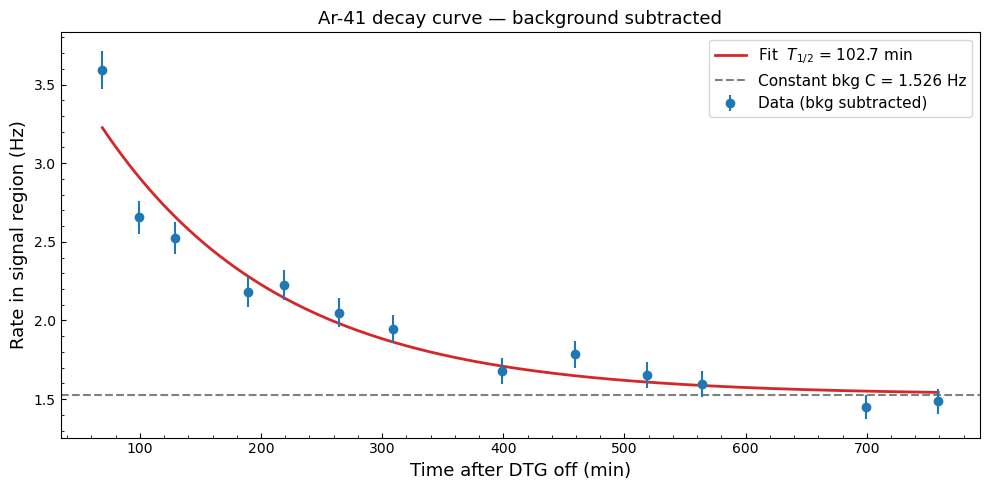

In [40]:
AR41_HALFLIFE_MIN = 109.61   # minutes

def decay_model(t, A, tau, C):
    """A·exp(-t·ln2/T½) + C  with T½ fixed to Ar-41 half-life."""
    return A * np.exp(-t * np.log(2) / tau) + C

# mask = [False, False, True, True, True, True, True, True, True, True, True]  # which windows to include in fit
# Fit only points with positive rates and finite errors
fit_mask = np.isfinite(rate_arr) & np.isfinite(rate_err_arr) & (rate_arr > 0)

if fit_mask.sum() >= 2:
    p0 = [rate_arr[fit_mask].max(), AR41_HALFLIFE_MIN, 0.0]
    try:
        popt, pcov = curve_fit(decay_model, t_min_arr[fit_mask], rate_arr[fit_mask],
                               sigma=rate_err_arr[fit_mask], absolute_sigma=True, p0=p0)
        perr = np.sqrt(np.diag(pcov))
        print(f"Fit result:  A = {popt[0]:.4f} ± {perr[0]:.4f} Hz")
        print(f"             τ = {popt[1]:.1f} ± {perr[1]:.1f} min  (half-life fixed to Ar-41)")
        print(f"             C = {popt[2]:.4f} ± {perr[2]:.4f} Hz")

        fit_ok = True
    except Exception as e:
        print(f"Fit failed: {e}")
        fit_ok = False
else:
    print("Not enough points for fit")
    fit_ok = False

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(t_min_arr[fit_mask], rate_arr[fit_mask], yerr=rate_err_arr[fit_mask],
            fmt="o", color="tab:blue", label="Data (bkg subtracted)", zorder=5)

if fit_ok:
    t_fine = np.linspace(t_min_arr.min(), t_min_arr.max(), 500)
    ax.plot(t_fine, decay_model(t_fine, *popt), color="tab:red", lw=2,
            label=fr"Fit  $T_{{1/2}}$ = {popt[1]:.1f} min")
    # ax.plot(t_fine, decay_model(t_fine, popt[0], AR41_HALFLIFE_MIN, popt[2]), color="tab:orange", lw=2,
    #         label=fr"Ar-41 fit  $T_{{1/2}}$ fixed to {AR41_HALFLIFE_MIN} min")
    ax.axhline(popt[2], ls="--", color="gray", label=f"Constant bkg C = {popt[2]:.3f} Hz")

ax.set_xlabel("Time after DTG off (min)", fontsize=13)
ax.set_ylabel("Rate in signal region (Hz)", fontsize=13)
ax.set_title("Ar-41 decay curve — background subtracted", fontsize=13)
ax.legend(fontsize=11)
# ax.set_yscale("log")
# ax.set_xscale("log")
ax.minorticks_on()
ax.tick_params(direction="in", which="both")
plt.tight_layout()
plt.show()
